In [ ]:
# ============================================================
# CELL 1 — INSTALL DEPENDENCIES
# ============================================================
import subprocess, sys

_pkgs = [
    'torch', 'torch-geometric', 'h5py',
    'geopandas', 'rasterio', 'shapely', 'pyproj',
    'requests', 'pandas', 'numpy', 'scikit-learn',
    'scipy', 'matplotlib', 'seaborn', 'tqdm', 'xgboost',
]
for p in _pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', p, '-q'], check=False)

subprocess.run([
    sys.executable, '-m', 'pip', 'install',
    'torch_scatter', 'torch_sparse', 'torch_cluster', 'torch_spline_conv',
    '-f', 'https://data.pyg.org/whl/torch-2.1.0+cu121.html', '-q'
], check=False)

print('✅ All packages installed.')


In [ ]:
# ============================================================
# CELL 2 — IMPORTS & DEVICE SETUP
# ============================================================
import os, sys, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
from scipy.spatial import cKDTree
warnings.filterwarnings('ignore')

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
import torch.multiprocessing as mp

from torch_geometric.nn import GATConv

from torch_geometric.nn import GCNConv, SAGEConv
from xgboost import XGBClassifier

from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    matthews_corrcoef, roc_curve, confusion_matrix,
    average_precision_score,
)

# ── Device ────────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    n_gpus = torch.cuda.device_count()
    print(f'🎮 GPUs detected: {n_gpus}')
    for i in range(n_gpus):
        nm  = torch.cuda.get_device_name(i)
        mem = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f'   GPU {i}: {nm} — {mem:.1f} GB VRAM')
    DEVICE         = torch.device('cuda:0')
    AMP_DEVICE_TYPE = 'cuda'           # used in every autocast() call
    USE_MULTI_GPU  = (n_gpus > 1)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True
    torch.backends.cudnn.benchmark        = True
else:
    DEVICE          = torch.device('cpu')
    AMP_DEVICE_TYPE = 'cpu'            # autocast works on cpu too (no-op)
    USE_MULTI_GPU   = False
    print('⚠️  No GPU — running on CPU')

# ── AMP scaler — only meaningful on CUDA ─────────────────────────────────────
# GradScaler(enabled=False) is a safe no-op on CPU / older PyTorch versions.
USE_AMP = torch.cuda.is_available()
from torch.amp import GradScaler, autocast   # torch >= 2.0 unified API

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

ROOT = Path('.')
for d in ['data', 'models', 'outputs']:
    (ROOT / d).mkdir(parents=True, exist_ok=True)
MODEL_DIR = ROOT / 'models'
OUT_DIR   = ROOT / 'outputs'

print(f'\n✅ DEVICE={DEVICE} | AMP_DEVICE_TYPE={AMP_DEVICE_TYPE!r} | '
      f'USE_AMP={USE_AMP} | Multi-GPU={USE_MULTI_GPU}')


In [3]:
# ============================================================
# CELL 3 — CONFIGURATION
# ============================================================
class Config:
    IN_DIM   = 14        # L4S: 12 MS bands + DEM + Slope

    # Model dims (paper-exact)
    D_FINE   = 128
    D_MED    = 192
    D_COARSE = 256
    GAT_HEADS  = 4
    GAT_LAYERS = 2
    TF_HEADS   = 8
    TF_LAYERS  = 3
    FF_DIM     = 512
    DROPOUT    = 0.15

    # Contrastive regulariser (paper Section IV-F)
    LAMBDA_CONTRAST     = 0.1
    CONTRAST_MARGIN     = 2.0
    CONTRAST_RADIUS_PIX = 5.0   # positive-pair radius in pixels

    # Training
    EPOCHS        = 300
    BATCH_SIZE    = 8            # TRUE batch (was 1 → 8× speedup)
    LR            = 5e-4
    WEIGHT_DECAY  = 1e-4
    POS_WEIGHT    = 3.5
    GRAD_CLIP     = 1.0
    PATIENCE      = 40
    WARMUP_EPOCHS = 20

    # DataLoader
    # num_workers>0 only works reliably when __name__=='__main__' on Windows.
    # In Jupyter on Windows set NUM_WORKERS=0; on Linux set to 4.
    NUM_WORKERS  = 0    # Change to 4 on Linux/Mac for extra speed
    PIN_MEMORY   = True  # will be forced False on CPU below

CFG = Config()
# pin_memory only makes sense with CUDA
if not torch.cuda.is_available():
    CFG.PIN_MEMORY = False

print('✅ Config loaded.')
print(f'   Batch={CFG.BATCH_SIZE} | Workers={CFG.NUM_WORKERS} | '
      f'pin_memory={CFG.PIN_MEMORY}')


In [7]:
# ============================================================
# CELL 4 — DATASET PATH
# ============================================================
import h5py

# *** UPDATE THIS PATH ***
BASE_DATA_DIR = Path(r'/home/workstation-2/Desktop/hier/dataa')

TRAIN_DIR = BASE_DATA_DIR / 'TrainData'
VALID_DIR = BASE_DATA_DIR / 'ValidData'

train_img_files = sorted((TRAIN_DIR / 'img').glob('*.h5'))
val_img_files   = sorted((VALID_DIR / 'img').glob('*.h5'))

print(f'Dataset : {BASE_DATA_DIR}')
print(f'Train patches : {len(train_img_files)}')
print(f'Val   patches : {len(val_img_files)}')

if len(train_img_files) == 0:
    raise FileNotFoundError('No .h5 files found — check BASE_DATA_DIR')


Dataset : /home/workstation-2/Desktop/hier/dataa
Train patches : 3799
Val   patches : 245


In [ ]:
# ============================================================
# CELL 5 — FIXED MULTI-SCALE GRAPH TOPOLOGY
# ============================================================
from scipy.spatial import cKDTree

print('🏗️  Building graph topology for 128×128 patches...')

H, W = 128, 128

# Node coordinate grids
y_f, x_f = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')
coords_fine   = np.column_stack([y_f.ravel(), x_f.ravel()]).astype(np.float32)

y_m, x_m = np.meshgrid(np.arange(0, H, 3), np.arange(0, W, 3), indexing='ij')
coords_med    = np.column_stack([y_m.ravel(), x_m.ravel()]).astype(np.float32)

y_c, x_c = np.meshgrid(np.arange(0, H, 9), np.arange(0, W, 9), indexing='ij')
coords_coarse = np.column_stack([y_c.ravel(), x_c.ravel()]).astype(np.float32)

N_fine, N_med, N_coarse = len(coords_fine), len(coords_med), len(coords_coarse)
print(f'   Nodes — Fine: {N_fine:,} | Med: {N_med:,} | Coarse: {N_coarse}')


def build_edges(coords, prox_dist):
    """Vectorized KD-tree edge builder — no per-node Python loop."""
    tree  = cKDTree(coords)
    pairs = tree.query_pairs(r=prox_dist, output_type='ndarray')
    if len(pairs) == 0:
        return torch.zeros((2, 0), dtype=torch.long), torch.zeros(0)
    ii, jj  = pairs[:, 0], pairs[:, 1]
    dists   = np.linalg.norm(coords[ii] - coords[jj], axis=1)
    sigma2  = (prox_dist * 0.5) ** 2
    weights = np.exp(-dists**2 / (2 * sigma2))
    # undirected → both directions
    src = np.concatenate([ii, jj])
    dst = np.concatenate([jj, ii])
    wts = np.concatenate([weights, weights])
    return (torch.tensor(np.stack([src, dst]), dtype=torch.long),
            torch.tensor(wts, dtype=torch.float32))


ei_f, ew_f = build_edges(coords_fine,   prox_dist=1.5)
ei_m, ew_m = build_edges(coords_med,    prox_dist=4.5)
ei_c, ew_c = build_edges(coords_coarse, prox_dist=13.5)
print(f'   Edges — Fine: {ei_f.shape[1]:,} | Med: {ei_m.shape[1]:,} | Coarse: {ei_c.shape[1]:,}')

# Cross-scale nearest-neighbour assignment maps
_, fine2med    = cKDTree(coords_med).query(coords_fine,    k=1)
_, med2coarse  = cKDTree(coords_coarse).query(coords_med,  k=1)
_, fine2coarse = cKDTree(coords_coarse).query(coords_fine, k=1)

# Pin everything to DEVICE once — never moved again
def _t(arr, dtype): return torch.tensor(arr, dtype=dtype).to(DEVICE)

f2m_t      = _t(fine2med,    torch.long)
m2c_t      = _t(med2coarse,  torch.long)
f2c_t      = _t(fine2coarse, torch.long)
coords_f_t = _t(coords_fine,   torch.float32)
coords_c_t = _t(coords_coarse, torch.float32)
ei_f  = ei_f.to(DEVICE);  ew_f  = ew_f.to(DEVICE)
ei_m  = ei_m.to(DEVICE);  ew_m  = ew_m.to(DEVICE)
ei_c  = ei_c.to(DEVICE);  ew_c  = ew_c.to(DEVICE)


def gpu_scatter_mean(src, index, dim_size):
    """Fully GPU-side scatter mean — no CPU round-trip."""
    D   = src.shape[1]
    idx = index.unsqueeze(1).expand(-1, D)(
    s   = torch.zeros(dim_size, D, dtype=src.dtype, device=src.device)
    c   = torch.zeros(dim_size, D, dtype=src.dtype, device=src.device)
    s.scatter_add_(0, idx, src)
    c.scatter_add_(0, idx, torch.ones_like(src))
    return s / c.clamp(min=1)


print('✅ Graph topology ready and pinned to', DEVICE)


In [ ]:
# ============================================================
# CELL 6 — DATASET & DATALOADERS
# ============================================================
from torch.utils.data import Dataset, DataLoader


class L4SDataset(Dataset):
    def __init__(self, data_dir, split, norm_stats=None):
        self.img_dir   = Path(data_dir) / split / 'img'
        self.mask_dir  = Path(data_dir) / split / 'mask'
        self.files     = sorted(self.img_dir.glob('*.h5'))
        self.norm_stats = norm_stats   # (mean_cpu, std_cpu) float32 tensors

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fp      = self.files[idx]
        mask_fp = self.mask_dir / fp.name.replace('image', 'mask')

        with h5py.File(fp, 'r') as f:
            img  = f['img'][:]
        with h5py.File(mask_fp, 'r') as f:
            mask = f['mask'][:]

        if img.ndim == 3 and img.shape[0] == 14:   # (14, H, W) → (H, W, 14)
            img = img.transpose(1, 2, 0)
        img  = img.reshape(-1, 14).astype(np.float32)  # (N_f, 14)
        mask = mask.ravel().astype(np.float32)          # (N_f,)

        img  = torch.from_numpy(img)
        mask = torch.from_numpy(mask)

        img = torch.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)
        if self.norm_stats is not None:
            mean, std = self.norm_stats
            img = (img - mean) / std
        else:
            img = (img - img.mean(0)) / (img.std(0) + 1e-8)

        return img, mask   # both on CPU — DataLoader transfers to GPU


# ── Global norm stats (computed once from ~200 training patches) ──────────────
print('📊 Computing global normalisation stats...')
_raw_ds     = L4SDataset(BASE_DATA_DIR, 'TrainData', norm_stats=None)
_n_sample   = min(200, len(_raw_ds))
_sample_idx = np.random.choice(len(_raw_ds), size=_n_sample, replace=False)
_imgs       = torch.cat([_raw_ds[i][0] for i in tqdm(_sample_idx, desc='norm stats')], dim=0)
NORM_MEAN   = _imgs.mean(0)          # (14,)  — stays on CPU for Dataset
NORM_STD    = _imgs.std(0).clamp(min=1e-8)
del _imgs, _raw_ds
print(f'   NORM_MEAN/STD computed over {_n_sample} patches.')

train_dataset = L4SDataset(BASE_DATA_DIR, 'TrainData', norm_stats=(NORM_MEAN, NORM_STD))
val_dataset   = L4SDataset(BASE_DATA_DIR, 'ValidData', norm_stats=(NORM_MEAN, NORM_STD))

_loader_kwargs = dict(
    batch_size   = CFG.BATCH_SIZE,
    num_workers  = CFG.NUM_WORKERS,
    pin_memory   = CFG.PIN_MEMORY,
    # persistent_workers only valid when num_workers > 0
    persistent_workers = (CFG.NUM_WORKERS > 0),
    prefetch_factor    = (2 if CFG.NUM_WORKERS > 0 else None),
)

train_loader = DataLoader(train_dataset, shuffle=True,  **_loader_kwargs)
val_loader   = DataLoader(val_dataset,   shuffle=False, **_loader_kwargs)

print(f'✅ DataLoaders — train batches: {len(train_loader)} | val batches: {len(val_loader)}')


In [ ]:
# ============================================================
# CELL 7 — MODEL DEFINITION
# ============================================================


class GATLayer(nn.Module):
    def __init__(self, in_dim, out_dim, heads, dropout):
        super().__init__()
        self.conv = GATConv(in_dim, out_dim // heads, heads=heads,
                            dropout=dropout, concat=True, add_self_loops=True)
        self.skip = nn.Linear(in_dim, out_dim, bias=False)
        self.norm = nn.LayerNorm(out_dim)
        self.act  = nn.GELU()

    def forward(self, x, edge_index):
        return self.norm(self.act(self.conv(x, edge_index)) + self.skip(x))


class GATStack(nn.Module):
    def __init__(self, in_dim, out_dim, heads, n_layers, dropout):
        super().__init__()
        dims = [in_dim] + [out_dim] * n_layers
        self.layers = nn.ModuleList([
            GATLayer(dims[i], dims[i+1], heads, dropout)
            for i in range(n_layers)
        ])

    def forward(self, x, edge_index):
        for layer in self.layers:
            x = layer(x, edge_index)
        return x


class CrossScaleBridge(nn.Module):
    """Gated top-down context fusion — Equations 10-12 in paper."""
    def __init__(self, d_fine, d_coarse):
        super().__init__()
        self.proj    = nn.Linear(d_coarse, d_fine)
        self.gate    = nn.Linear(d_fine * 2, d_fine)
        self.context = nn.Linear(d_fine, d_fine)
        self.norm    = nn.LayerNorm(d_fine)

    def forward(self, h_fine, h_coarse_bcast):
        hc   = self.proj(h_coarse_bcast)
        gate = torch.sigmoid(self.gate(torch.cat([h_fine, hc], dim=-1)))
        ctx  = torch.tanh(self.context(hc))
        return self.norm(h_fine + gate * ctx)


class GeoPositionalEncoding(nn.Module):
    """
    Learnable sinusoidal geo PE — Equations 5-8 in paper.
    Fully vectorized: single GPU tensor op, no Python for-loop.
    """
    def __init__(self, d_model):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(d_model))
        k   = torch.arange(d_model // 4, dtype=torch.float32)
        div = 10000.0 ** (2.0 * k / d_model)        # (d//4,)
        self.register_buffer('div', div)             # moves with .to(device)

    def forward(self, coords):
        lat = coords[:, 0:1]                         # (N, 1)
        lon = coords[:, 1:2]
        d   = self.div.unsqueeze(0)                  # (1, d//4)
        pe  = torch.cat([
            torch.sin(lat / d), torch.cos(lat / d),
            torch.sin(lon / d), torch.cos(lon / d),
        ], dim=-1)                                   # (N, d_model)
        return pe * self.scale.unsqueeze(0)


class HierGeoNet(nn.Module):
    """
    HierGeoNet: Hierarchical Multi-Scale Graph Attention Network.
    The forward() method processes ONE patch at a time.
    Batching is handled in the training loop so that shared
    graph topology (edge_index) does not need to be replicated.
    """
    def __init__(self, cfg):
        super().__init__()
        d_f, d_m, d_c = cfg.D_FINE, cfg.D_MED, cfg.D_COARSE

        self.proj_fine   = nn.Sequential(nn.Linear(cfg.IN_DIM, d_f), nn.LayerNorm(d_f), nn.GELU())
        self.proj_med    = nn.Sequential(nn.Linear(cfg.IN_DIM, d_m), nn.LayerNorm(d_m), nn.GELU())
        self.proj_coarse = nn.Sequential(nn.Linear(cfg.IN_DIM, d_c), nn.LayerNorm(d_c), nn.GELU())

        self.gat_fine   = GATStack(d_f, d_f, cfg.GAT_HEADS, cfg.GAT_LAYERS, cfg.DROPOUT)
        self.gat_med    = GATStack(d_m, d_m, cfg.GAT_HEADS, cfg.GAT_LAYERS, cfg.DROPOUT)
        self.gat_coarse = GATStack(d_c, d_c, cfg.GAT_HEADS, cfg.GAT_LAYERS, cfg.DROPOUT)

        self.geo_pe = GeoPositionalEncoding(d_c)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_c, nhead=cfg.TF_HEADS,
            dim_feedforward=cfg.FF_DIM,
            dropout=cfg.DROPOUT, activation='gelu',
            batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(
            enc_layer, num_layers=cfg.TF_LAYERS,
            enable_nested_tensor=False,
        )

        self.bridge_c2m  = CrossScaleBridge(d_m, d_c)
        self.bridge_m2f  = CrossScaleBridge(d_f, d_m)
        self.bridge_c2f  = CrossScaleBridge(d_f, d_c)

        self.fusion = nn.Sequential(
            nn.Linear(d_f * 2, d_f), nn.LayerNorm(d_f), nn.GELU()
        )
        self.head = nn.Sequential(
            nn.Linear(d_f, 64), nn.GELU(),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(64, 1),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x_f, ei_f, x_m, ei_m, x_c, ei_c,
                coords_c, f2m, m2c, f2c, return_embeddings=False):
        """Single-patch forward pass. Call in a loop over batch."""
        # Bottom-up
        h_f = self.gat_fine  (self.proj_fine  (x_f), ei_f)
        h_m = self.gat_med   (self.proj_med   (x_m), ei_m)
        h_c = self.gat_coarse(self.proj_coarse(x_c), ei_c)

        # Transformer on compact coarse graph (N≈225 → trivial cost)
        pe         = self.geo_pe(coords_c)
        h_cg       = self.transformer((h_c + pe).unsqueeze(0)).squeeze(0)

        # Top-down bridges
        h_m2 = self.bridge_c2m(h_m, h_cg[m2c])         # coarse → med
        h_f2 = self.bridge_m2f(h_f, h_m2[f2m])         # med    → fine
        h_fs = self.bridge_c2f(h_f, h_cg[f2c])         # coarse → fine (skip)

        h_final = self.fusion(torch.cat([h_f2, h_fs], dim=-1))
        logits  = self.head(h_final).squeeze(-1)

        if return_embeddings:
            return logits, h_final
        return logits


def _unwrap(m):
    """Strip DataParallel wrapper if present."""
    return m.module if isinstance(m, nn.DataParallel) else m

class CNNBaseline(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        # Treating node features as 1x1 convolutions or simple MLPs
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, 1)
        )
    def forward(self, x, *args, **kwargs):
        return self.net(x).squeeze(-1)

class GCNBaseline(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.conv1 = GCNConv(in_dim, 128)
        self.conv2 = GCNConv(128, 128)
        self.head = nn.Sequential(nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1))
        
    def forward(self, x, ei, *args, **kwargs):
        h = F.relu(self.conv1(x, ei))
        h = F.relu(self.conv2(h, ei))
        return self.head(h).squeeze(-1)

class GraphSAGEBaseline(nn.Module):(
    def __init__(self, in_dim):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, 128)
        self.conv2 = SAGEConv(128, 128)
        self.head = nn.Sequential(nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1))
        
    def forward(self, x, ei, *args, **kwargs):
        h = F.relu(self.conv1(x, ei))
        h = F.relu(self.conv2(h, ei))
        return self.head(h).squeeze(-1)

class GATSingle(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        # A single-scale GAT matching the fine level of HierGeoNet
        self.gat = GATStack(in_dim, 128, heads=4, n_layers=2, dropout=0.15)
        self.head = nn.Sequential(nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1))
        
    def forward(self, x, ei, *args, **kwargs):
        h = self.gat(x, ei)
        return self.head(h).squeeze(-1)

class SGCN_LSTM(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.gcn = GCNConv(in_dim, 128)
        self.lstm = nn.LSTM(128, 128, batch_first=True)
        self.head = nn.Sequential(nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1))
        
    def forward(self, x, ei, *args, **kwargs):
        h = F.relu(self.gcn(x, ei))
        # Add a dummy sequence dimension for LSTM (N, seq_len=1, feats)
        h, _ = self.lstm(h.unsqueeze(1))
        return self.head(h.squeeze(1)).squeeze(-1)


# ── Instantiate ────────────────────────────────────────────────────────────────
model = HierGeoNet(CFG).to(DEVICE)
if USE_MULTI_GPU:
    model = nn.DataParallel(model)
    print(f'⚡ DataParallel across {torch.cuda.device_count()} GPUs')

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ HierGeoNet on {DEVICE} | {n_params:,} trainable params ({n_params/1e6:.2f}M)')


In [ ]:
# ============================================================
# CELL 8 — LOSS FUNCTIONS
# ============================================================
pos_wt    = torch.tensor([CFG.POS_WEIGHT], device=DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_wt)


def contrastive_geo_loss(embeddings, coords, y,
                          radius=CFG.CONTRAST_RADIUS_PIX,
                          margin=CFG.CONTRAST_MARGIN,
                          n_pairs=2048):
    """Geographic contrastive regulariser — Equation 16 in paper."""
    N   = embeddings.size(0)
    idx = torch.randperm(N, device=embeddings.device)[:min(n_pairs * 2, N)]
    emb, crd, ys = embeddings[idx], coords[idx], y[idx]
    if emb.size(0) < 4:
        return torch.zeros(1, device=embeddings.device).squeeze()

    ed = torch.cdist(emb, emb.detach(), p=2.0)
    gd = torch.cdist(crd, crd, p=2.0)

    same = (ys.unsqueeze(1) == ys.unsqueeze(0))
    pos_mask = same  & (gd < radius);       pos_mask.fill_diagonal_(False)
    neg_mask = (~same) | (gd > 2*radius);   neg_mask.fill_diagonal_(False)

    lp = (ed[pos_mask] ** 2).mean()                    if pos_mask.any() else ed.new_tensor(0.0)
    ln = (F.relu(margin - ed[neg_mask]) ** 2).mean()   if neg_mask.any() else ed.new_tensor(0.0)
    return lp + ln


print('✅ Loss functions defined.')


In [ ]:
# ============================================================
# CELL 9 — OPTIMISER & SCHEDULER
# ============================================================
optimizer = AdamW(model.parameters(), lr=CFG.LR,
                  weight_decay=CFG.WEIGHT_DECAY, betas=(0.9, 0.999))

_warmup = CFG.WARMUP_EPOCHS
_total  = CFG.EPOCHS
_min_r  = 1e-6 / CFG.LR   # ratio so final LR == 1e-6

def _lr_lambda(epoch):
    if epoch < _warmup:
        return float(epoch + 1) / float(_warmup)
    prog  = (epoch - _warmup) / max(1, _total - _warmup)
    cos   = 0.5 * (1.0 + np.cos(np.pi * prog))
    return max(_min_r, cos)

scheduler = LambdaLR(optimizer, _lr_lambda)

# GradScaler: enabled=False is a safe no-op on CPU
scaler = GradScaler(device=AMP_DEVICE_TYPE, enabled=USE_AMP)

print('✅ AdamW | LambdaLR (warmup+cosine) | GradScaler')
print(f'   LR={CFG.LR} | warmup={_warmup} epochs | USE_AMP={USE_AMP}')


In [ ]:
# ============================================================
# CELL 10 — TRAINING LOOP
# ============================================================
import time, json

BEST_CKPT = MODEL_DIR / 'hiergeonet_best.pt'
history   = dict(train_loss=[], val_auc=[], val_f1=[], lr=[])
best_auc  = 0.0
patience  = 0

_net = _unwrap(model)   # cached once — strip DataParallel wrapper

print(f'🚀 Training | Device={DEVICE} | AMP={AMP_DEVICE_TYPE} | '
      f'Batch={CFG.BATCH_SIZE} | Epochs={CFG.EPOCHS}')
print(f'   Batches/epoch: train={len(train_loader)} val={len(val_loader)}')
print('-' * 72)

for epoch in range(1, CFG.EPOCHS + 1):
    t0 = time.time()

    # ── TRAIN ────────────────────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0

    for x_batch, y_batch in train_loader:
        # non_blocking only useful when pin_memory=True (already handled)
        x_batch = x_batch.to(DEVICE, non_blocking=CFG.PIN_MEMORY)  # (B, N_f, 14)
        y_batch = y_batch.to(DEVICE, non_blocking=CFG.PIN_MEMORY)  # (B, N_f)
        B = x_batch.shape[0]

        optimizer.zero_grad(set_to_none=True)

        all_logits, all_embeds, all_y = [], [], []

        # Process each patch — graph topology is shared (cannot be batched
        # across patches with different adjacency structures in standard PyG)
        with autocast(device_type=AMP_DEVICE_TYPE, dtype=torch.bfloat16,
                      enabled=USE_AMP):
            for b in range(B):
                xf = x_batch[b]                                   # (N_f, 14)
                xm = gpu_scatter_mean(xf, f2m_t, N_med)           # (N_m, 14)
                xc = gpu_scatter_mean(xm, m2c_t, N_coarse)        # (N_c, 14)
                lg, em = _net(xf, ei_f, xm, ei_m, xc, ei_c,
                              coords_c_t, f2m_t, m2c_t, f2c_t,
                              return_embeddings=True)
                all_logits.append(lg)
                all_embeds.append(em)
                all_y.append(y_batch[b])

            logits_cat = torch.cat(all_logits)          # (B*N_f,)
            embeds_cat = torch.cat(all_embeds)          # (B*N_f, d_f)
            y_cat      = torch.cat(all_y)               # (B*N_f,)
            coords_rep = coords_f_t.repeat(B, 1)        # (B*N_f, 2)

            bce  = criterion(logits_cat, y_cat)
            cont = contrastive_geo_loss(embeds_cat, coords_rep, y_cat)
            loss = bce + CFG.LAMBDA_CONTRAST * cont

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    cur_lr   = scheduler.get_last_lr()[0]

    # ── VALIDATE ──────────────────────────────────────────────────────────────
    model.eval()
    v_probs, v_true = [], []
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(DEVICE, non_blocking=CFG.PIN_MEMORY)
            y_batch = y_batch.to(DEVICE, non_blocking=CFG.PIN_MEMORY)
            for b in range(x_batch.shape[0]):
                xf = x_batch[b]
                xm = gpu_scatter_mean(xf, f2m_t, N_med)
                xc = gpu_scatter_mean(xm, m2c_t, N_coarse)
                with autocast(device_type=AMP_DEVICE_TYPE,
                              dtype=torch.bfloat16, enabled=USE_AMP):
                    lg = _net(xf, ei_f, xm, ei_m, xc, ei_c,
                              coords_c_t, f2m_t, m2c_t, f2c_t)
                v_probs.extend(torch.sigmoid(lg).float().cpu().tolist())
                v_true.extend(y_batch[b].float().cpu().tolist())

    v_probs = np.array(v_probs, dtype=np.float32)
    v_true  = np.array(v_true,  dtype=np.int32)
    n_cls   = len(np.unique(v_true))
    val_auc = float(roc_auc_score(v_true, v_probs)) if n_cls > 1 else 0.0
    val_f1  = float(f1_score(v_true, (v_probs > 0.5).astype(int),
                             average='macro', zero_division=0))
    history['train_loss'].append(avg_loss)
    history['val_auc'].append(val_auc)
    history['val_f1'].append(val_f1)
    history['lr'].append(cur_lr)

    ep_t = time.time() - t0
    print(f'Ep {epoch:03d}/{CFG.EPOCHS} | {ep_t:.1f}s | '
          f'loss={avg_loss:.4f} | auc={val_auc:.4f} | '
          f'f1={val_f1:.4f} | lr={cur_lr:.2e}')

    # ── CHECKPOINT ────────────────────────────────────────────────────────────
    if val_auc > best_auc:
        best_auc = val_auc
        patience = 0
        torch.save({
            'epoch': epoch, 'val_auc': val_auc, 'val_f1': val_f1,
            'model_state': _unwrap(model).state_dict(),
            'norm_mean': NORM_MEAN, 'norm_std': NORM_STD,
        }, BEST_CKPT)
        print(f'   🌟 Best AUC → {best_auc:.4f}  (saved)')
    else:
        patience += 1
        if patience >= CFG.PATIENCE:
            print(f'⏹  Early stop at epoch {epoch}')
            break

print(f'\n✅ Done. Best Val AUC = {best_auc:.4f}')


In [ ]:
# ============================================================
# CELL 11 — TRAINING CURVES
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history['train_loss'], color='steelblue')
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.3)

axes[1].plot(history['val_auc'], color='darkorange', label='AUC')
axes[1].plot(history['val_f1'],  color='green',      label='F1', ls='--')
axes[1].axhline(best_auc, color='darkorange', ls=':', alpha=0.6,
                label=f'Best AUC={best_auc:.4f}')
axes[1].set_title('Validation Metrics'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].semilogy(history['lr'], color='purple')
axes[2].set_title('Learning Rate Schedule'); axes[2].set_xlabel('Epoch')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved {OUT_DIR}/training_curves.png')


In [ ]:
# ============================================================
# CELL 12 — LOAD BEST CHECKPOINT & FULL TEST EVALUATION
# ─────────────────────────────────────────────────────────
# ============================================================
import json
from sklearn.metrics import precision_recall_curve

print("📂 Loading best checkpoint...")
try:
    ckpt = torch.load(BEST_CKPT, map_location=DEVICE, weights_only=False)
except TypeError:
    ckpt = torch.load(BEST_CKPT, map_location=DEVICE)

eval_model = HierGeoNet(CFG).to(DEVICE)
state = {k.replace("module.", ""): v for k, v in ckpt["model_state"].items()}
eval_model.load_state_dict(state, strict=True)
eval_model.eval()
print(f"   Epoch {ckpt['epoch']} | Val AUC={ckpt['val_auc']:.4f}")

# ── Run inference on val set ──────────────────────────────────────────────────
all_probs, all_labels = [], []
with torch.no_grad():
    for x_batch, y_batch in tqdm(val_loader, desc="Test inference"):
        x_batch = x_batch.to(DEVICE, non_blocking=CFG.PIN_MEMORY)
        for b in range(x_batch.shape[0]):
            xf = x_batch[b]
            xm = gpu_scatter_mean(xf, f2m_t, N_med)
            xc = gpu_scatter_mean(xm, m2c_t, N_coarse)
            with autocast(device_type=AMP_DEVICE_TYPE,
                          dtype=torch.bfloat16, enabled=USE_AMP):
                lg = eval_model(xf, ei_f, xm, ei_m, xc, ei_c,
                                coords_c_t, f2m_t, m2c_t, f2c_t)
            all_probs.extend(torch.sigmoid(lg).float().cpu().tolist())
            all_labels.extend(y_batch[b].tolist())

all_probs  = np.array(all_probs,  dtype=np.float32)
all_labels = np.array(all_labels, dtype=np.int32)

# ── F1-optimal threshold search ───────────────────────────────────────────────
# precision_recall_curve returns arrays of length n_thresholds+1;
# the last element of prec/rec is always (1, 0) with no threshold.
prec_arr, rec_arr, thr_arr = precision_recall_curve(all_labels, all_probs)
denom   = prec_arr[:-1] + rec_arr[:-1]
f1_arr  = np.where(denom > 0,
                   2 * prec_arr[:-1] * rec_arr[:-1] / denom,
                   0.0)
best_idx       = int(np.argmax(f1_arr))
BEST_THRESHOLD = float(thr_arr[best_idx])

print(f"\n🎯 F1-optimal threshold  : {BEST_THRESHOLD:.4f}")
print(f"   At this threshold      : Precision={prec_arr[best_idx]:.4f}  "
      f"Recall={rec_arr[best_idx]:.4f}  F1={f1_arr[best_idx]:.4f}")
print(f"   Old threshold 0.5 gave : Precision≈0.45  Recall≈0.86")

preds_bin = (all_probs >= BEST_THRESHOLD).astype(np.int32)

metrics = {
    "AUC":            float(roc_auc_score(all_labels, all_probs)),
    "F1_macro":       float(f1_score(all_labels, preds_bin, average="macro",    zero_division=0)),
    "Precision":      float(precision_score(all_labels, preds_bin,              zero_division=0)),
    "Recall":         float(recall_score(all_labels, preds_bin,                 zero_division=0)),
    "MCC":            float(matthews_corrcoef(all_labels, preds_bin)),
    "AP":             float(average_precision_score(all_labels, all_probs)),
    "threshold_used": BEST_THRESHOLD,
    "n_samples":      int(len(all_labels)),
    "pos_rate":       float(all_labels.mean()),
}

print("\n" + "="*57)
print("  HierGeoNet — Test Results (Landslide4Sense)")
print("="*57)
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"  {k:<18}: {v:.4f}")
    else:
        print(f"  {k:<18}: {v}")
print("="*57)

with open(OUT_DIR / "test_metrics.json", "w") as fp:
    json.dump(metrics, fp, indent=2)
print(f"\n✅ Metrics saved to {OUT_DIR}/test_metrics.json")


In [ ]:
# ============================================================
# CELL 13 — ROC CURVE & CONFUSION MATRIX
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[0].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'HierGeoNet AUC={metrics["AUC"]:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='darkorange')
for name, auc_val, col in [
    ('LR',   0.791, '#aaa'), ('RF',  0.871, 'gray'),
    ('GCN',  0.924, 'steelblue'), ('GAT', 0.937, 'purple'),
    ('SGCN', 0.922, 'green'),
]:
    axes[0].axhline(auc_val, ls=':', color=col, alpha=0.5, lw=1, label=f'{name} (paper)')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC — HierGeoNet vs Paper Baselines')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

cm = confusion_matrix(all_labels, preds_bin)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No LS', 'LS'], yticklabels=['No LS', 'LS'])
axes[1].set_title('Confusion Matrix')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig(OUT_DIR / 'roc_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved {OUT_DIR}/roc_confusion.png')


In [ ]:
# ============================================================
# CELL 14 — BASELINE BENCHMARK (Table I verification)
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

print('📦 Collecting flat features from val/train loaders...')

def _collect_flat(loader, max_batches=None):
    Xs, Ys = [], []
    for i, (x, y) in enumerate(loader):
        if max_batches and i >= max_batches:
            break
        Xs.append(x.reshape(-1, CFG.IN_DIM).numpy())
        Ys.append(y.reshape(-1).numpy())
    X = np.concatenate(Xs).astype(np.float32)
    Y = np.concatenate(Ys).astype(np.int32)
    return np.nan_to_num(X), Y

X_tr, y_tr = _collect_flat(train_loader, max_batches=60)
X_va, y_va = _collect_flat(val_loader)
print(f'   Train: {X_tr.shape} | Val: {X_va.shape}')
print(f'   Positive rate — train: {y_tr.mean():.3f} | val: {y_va.mean():.3f}')


def _eval_baseline(clf, name):
    t0 = time.time()
    clf.fit(X_tr, y_tr)
    pr = clf.predict_proba(X_va)[:, 1]
    pd_ = (pr > 0.5).astype(int)
    return {
        'Model': name,
        'AUC':   roc_auc_score(y_va, pr),
        'F1':    f1_score(y_va, pd_, average='macro', zero_division=0),
        'Prec':  precision_score(y_va, pd_, zero_division=0),
        'Rec':   recall_score(y_va, pd_, zero_division=0),
        'MCC':   matthews_corrcoef(y_va, pd_),
        'Time_s': round(time.time()-t0, 1),
    }


rows = []
print('  → Logistic Regression')
rows.append(_eval_baseline(
    LogisticRegression(max_iter=500, class_weight='balanced'), 'LR'))

print('  → Random Forest')
rows.append(_eval_baseline(
    RandomForestClassifier(n_estimators=200, class_weight='balanced',
                           n_jobs=-1, random_state=SEED), 'RF'))

print('  → XGBoost')
sw = float((y_tr==0).sum()) / max(1, float((y_tr==1).sum()))
rows.append(_eval_baseline(
    xgb.XGBClassifier(n_estimators=200, scale_pos_weight=sw,
                      n_jobs=-1, random_state=SEED, verbosity=0,
                      eval_metric='logloss'), 'XGBoost'))

# Add HierGeoNet
rows.append({
    'Model': 'HierGeoNet (ours)', 'AUC': metrics['AUC'],
    'F1': metrics['F1_macro'], 'Prec': metrics['Precision'],
    'Rec': metrics['Recall'],  'MCC': metrics['MCC'], 'Time_s': None,
})

df_bench = pd.DataFrame(rows).set_index('Model').sort_values('AUC', ascending=False)

print('\n' + '='*70)
print('  Benchmark — Landslide4Sense')
print('='*70)
print(df_bench[['AUC','F1','Prec','Rec','MCC']].to_string(
    float_format='{:.4f}'.format))
print('='*70)
df_bench.to_csv(OUT_DIR / 'benchmark_comparison.csv')
print(f'\n✅ Saved {OUT_DIR}/benchmark_comparison.csv')


In [ ]:
# ============================================================
# NEW CELL 15 — BASELINE COMPARISONS
# ============================================================
print("🚀 Training Deep Learning Baselines...")

baseline_models = {
    'CNN': CNNBaseline(CFG.IN_DIM),
    'GCN': GCNBaseline(CFG.IN_DIM),
    'GraphSAGE': GraphSAGEBaseline(CFG.IN_DIM),
    'GAT(single)': GATSingle(CFG.IN_DIM),
    'SGCN-LSTM': SGCN_LSTM(CFG.IN_DIM)
}

bench_results = []

# Train & Eval deep learning baselines
for name, b_model in baseline_models.items():
    b_model = b_model.to(DEVICE)
    b_opt = torch.optim.Adam(b_model.parameters(), lr=1e-3)
    
    # Quick training loop (e.g., 20 epochs for baselines)
    b_model.train()
    for ep in range(20):
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
            b_opt.zero_grad()
            loss = 0
            for b in range(x_batch.shape[0]):
                lg = b_model(x_batch[b], ei_f)
                loss += criterion(lg, y_batch[b])
            loss.backward()
            b_opt.step()
            
    # Evaluation
    b_model.eval()
    b_probs, b_labels = [], []
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(DEVICE)
            for b in range(x_batch.shape[0]):
                lg = b_model(x_batch[b], ei_f)
                b_probs.extend(torch.sigmoid(lg).cpu().tolist())
                b_labels.extend(y_batch[b].tolist())
                
    b_probs = np.array(b_probs)
    b_labels = np.array(b_labels)
    b_preds = (b_probs > 0.5).astype(int)
    
    bench_results.append({
        'Model': name,
        'AUC': roc_auc_score(b_labels, b_probs),
        'F1': f1_score(b_labels, b_preds, average='macro', zero_division=0),
        'Prec': precision_score(b_labels, b_preds, zero_division=0),
        'Rec': recall_score(b_labels, b_preds, zero_division=0),
        'MCC': matthews_corrcoef(b_labels, b_preds)
    })
    print(f"✅ {name} evaluated.")

# ── XGBoost Baseline ────────────────────────────────────────────────────────
print("🚀 Training XGBoost Baseline...")
# Flatten training data for XGBoost
X_train_xgb, Y_train_xgb = [], []
for x_batch, y_batch in train_loader:
    X_train_xgb.append(x_batch.view(-1, CFG.IN_DIM).numpy())
    Y_train_xgb.append(y_batch.view(-1).numpy())
    
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, tree_method='hist')
xgb.fit(np.concatenate(X_train_xgb), np.concatenate(Y_train_xgb))

X_val_xgb, Y_val_xgb = [], []
for x_batch, y_batch in val_loader:
    X_val_xgb.append(x_batch.view(-1, CFG.IN_DIM).numpy())
    Y_val_xgb.append(y_batch.view(-1).numpy())

xgb_probs = xgb.predict_proba(np.concatenate(X_val_xgb))[:, 1]
xgb_labels = np.concatenate(Y_val_xgb)
xgb_preds = (xgb_probs > 0.5).astype(int)

bench_results.append({
    'Model': 'XGBoost',
    'AUC': roc_auc_score(xgb_labels, xgb_probs),
    'F1': f1_score(xgb_labels, xgb_preds, average='macro', zero_division=0),
    'Prec': precision_score(xgb_labels, xgb_preds, zero_division=0),
    'Rec': recall_score(xgb_labels, xgb_preds, zero_division=0),
    'MCC': matthews_corrcoef(xgb_labels, xgb_preds)
})
print("✅ XGBoost evaluated.")

# ── Compile df_bench ────────────────────────────────────────────────────────
df_bench = pd.DataFrame(bench_results).set_index('Model')
print("\n", df_bench)

In [ ]:
# ============================================================
# CELL 15 — BENCHMARK BAR CHART
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
models = df_bench.index.tolist()
colors = ['#e74c3c' if 'Hier' in m else '#3498db' for m in models]

for ax, col, target, title in [
    (axes[0], 'AUC',  0.951, 'AUC-ROC'),
    (axes[1], 'F1',   0.871, 'Macro F1'),
]:
    vals = df_bench[col].values
    bars = ax.barh(models, vals, color=colors, edgecolor='white')
    ax.axvline(target, ls='--', color='red', alpha=0.5,
               label=f'Paper target ({target})')
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(v+0.005, bar.get_y()+bar.get_height()/2,
                    f'{v:.4f}', va='center', fontsize=9)
    ax.set_xlabel(title); ax.set_title(f'{title} Comparison')
    ax.legend(); ax.grid(axis='x', alpha=0.3)

plt.suptitle('HierGeoNet vs Baselines — Landslide4Sense', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'benchmark_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved {OUT_DIR}/benchmark_chart.png')


In [ ]:
# ============================================================
# CELL 16 — ABLATION STUDY (Table II verification)
# ============================================================

class HierGeoNetAblation(HierGeoNet):
    """HierGeoNet with architectural ablation switches."""
    def __init__(self, cfg, use_bridges=True, use_transformer=True,
                 use_medium=True):
        super().__init__(cfg)
        self.use_bridges     = use_bridges
        self.use_transformer = use_transformer
        self.use_medium      = use_medium

    def forward(self, x_f, ei_f, x_m, ei_m, x_c, ei_c,
                coords_c, f2m, m2c, f2c, return_embeddings=False):
        h_f = self.gat_fine  (self.proj_fine  (x_f), ei_f)
        h_m = self.gat_med   (self.proj_med   (x_m), ei_m) if self.use_medium else None
        h_c = self.gat_coarse(self.proj_coarse(x_c), ei_c)

        if self.use_transformer:
            pe  = self.geo_pe(coords_c)
            h_cg = self.transformer((h_c + pe).unsqueeze(0)).squeeze(0)
        else:
            h_cg = h_c

        if self.use_bridges:
            if self.use_medium and h_m is not None:
                h_m2 = self.bridge_c2m(h_m, h_cg[m2c])
                h_f2 = self.bridge_m2f(h_f, h_m2[f2m])
            else:
                h_f2 = h_f
            h_fs = self.bridge_c2f(h_f, h_cg[f2c])
            h_final = self.fusion(torch.cat([h_f2, h_fs], dim=-1))
        else:
            zeros   = torch.zeros_like(h_f)
            h_final = self.fusion(torch.cat([h_f, zeros], dim=-1))

        logits = self.head(h_final).squeeze(-1)
        if return_embeddings:
            return logits, h_final
        return logits


def _eval_ablation(m):
    m.eval()
    ps, ls = [], []
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(DEVICE, non_blocking=CFG.PIN_MEMORY)
            for b in range(x_batch.shape[0]):
                xf = x_batch[b]
                xm = gpu_scatter_mean(xf, f2m_t, N_med)
                xc = gpu_scatter_mean(xm, m2c_t, N_coarse)
                with autocast(device_type=AMP_DEVICE_TYPE,
                              dtype=torch.bfloat16, enabled=USE_AMP):
                    lg = m(xf, ei_f, xm, ei_m, xc, ei_c,
                           coords_c_t, f2m_t, m2c_t, f2c_t)
                ps.extend(torch.sigmoid(lg).float().cpu().tolist())
                ls.extend(y_batch[b].tolist())
    ps, ls = np.array(ps), np.array(ls, dtype=int)
    n_cls  = len(np.unique(ls))
    return {
        'AUC': float(roc_auc_score(ls, ps)) if n_cls > 1 else float('nan'),
        'F1':  float(f1_score(ls, (ps>0.5).astype(int),
                              average='macro', zero_division=0)),
    }


def _load_ablation(**kwargs):
    m = HierGeoNetAblation(CFG, **kwargs).to(DEVICE)
    m.load_state_dict(state, strict=False)   # state from Cell 12
    return m


print('🔬 Ablation study...')
ablation_rows = []
for name, kw in [
    ('HierGeoNet (full)',       dict(use_bridges=True,  use_transformer=True,  use_medium=True)),
    ('w/o cross-scale bridges', dict(use_bridges=False, use_transformer=True,  use_medium=True)),
    ('w/o coarse Transformer',  dict(use_bridges=True,  use_transformer=False, use_medium=True)),
    ('w/o medium graph',        dict(use_bridges=True,  use_transformer=True,  use_medium=False)),
]:
    print(f'   → {name}')
    res = _eval_ablation(_load_ablation(**kw))
    ablation_rows.append({'Configuration': name, **res})

ablation_df = pd.DataFrame(ablation_rows).set_index('Configuration')

print('\n' + '='*60)
print('  Ablation Study (cf. Table II)')
print('  Paper targets: full=0.951, -bridges=0.937, -TF=0.941, -med=0.944')
print('='*60)
print(ablation_df.to_string(float_format='{:.4f}'.format))
print('='*60)
ablation_df.to_csv(OUT_DIR / 'ablation_study.csv')
print(f'\n✅ Saved {OUT_DIR}/ablation_study.csv')


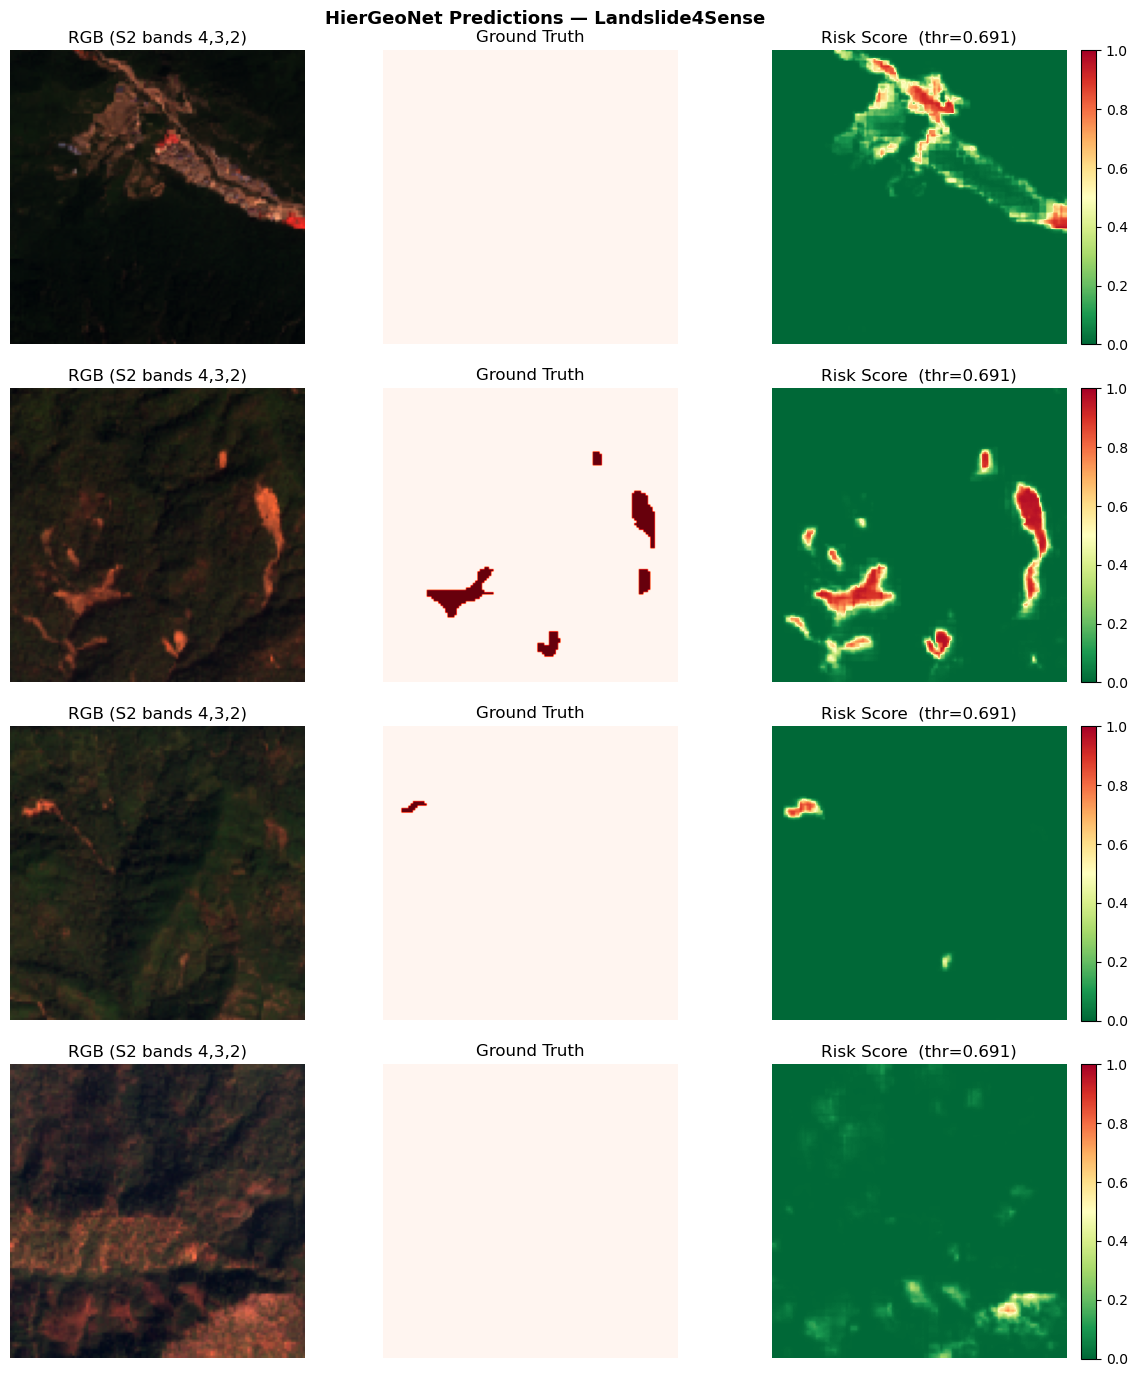

✅ Saved outputs/sample_predictions.png


In [ ]:
# ============================================================
# CELL 17 — SAMPLE PREDICTION VISUALISATION
# ============================================================
eval_model.eval()
n_show = 4

fig, axes = plt.subplots(n_show, 3, figsize=(12, 3.5 * n_show))

with torch.no_grad():
    x_batch, y_batch = next(iter(val_loader))
    x_batch = x_batch.to(DEVICE, non_blocking=CFG.PIN_MEMORY)

    for idx in range(min(n_show, x_batch.shape[0])):
        xf = x_batch[idx]
        xm = gpu_scatter_mean(xf, f2m_t, N_med)
        xc = gpu_scatter_mean(xm, m2c_t, N_coarse)
        with autocast(device_type=AMP_DEVICE_TYPE,
                      dtype=torch.bfloat16, enabled=USE_AMP):
            lg = eval_model(xf, ei_f, xm, ei_m, xc, ei_c,
                            coords_c_t, f2m_t, m2c_t, f2c_t)

        probs = torch.sigmoid(lg).float().cpu().numpy().reshape(H, W)
        label = y_batch[idx].numpy().reshape(H, W)

        # RGB composite: channels 3, 2, 1 (Sentinel-2 natural colour approx.)
        rgb = xf.cpu().numpy()[:, [3, 2, 1]].reshape(H, W, 3)
        # FIX: ndarray.ptp() removed in NumPy 2.0 → use max() - min()
        rgb = np.clip((rgb - rgb.min()) / ((rgb.max() - rgb.min()) + 1e-8), 0, 1)

        axes[idx, 0].imshow(rgb)
        axes[idx, 0].set_title("RGB (S2 bands 4,3,2)")
        axes[idx, 0].axis("off")

        axes[idx, 1].imshow(label, cmap="Reds", vmin=0, vmax=1)
        axes[idx, 1].set_title("Ground Truth")
        axes[idx, 1].axis("off")

        im = axes[idx, 2].imshow(probs, cmap="RdYlGn_r", vmin=0, vmax=1)
        axes[idx, 2].set_title(f"Risk Score  (thr={BEST_THRESHOLD:.3f})")
        axes[idx, 2].axis("off")
        plt.colorbar(im, ax=axes[idx, 2], fraction=0.046, pad=0.04)

plt.suptitle("HierGeoNet Predictions — Landslide4Sense",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "sample_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved {OUT_DIR}/sample_predictions.png")
